<a href="https://colab.research.google.com/github/erim908/IAT460_FinalProject/blob/main/IAT460_finalproject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip3 install matplotlib ipywidgets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 27.2 MB/s eta 0:00:00


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output
import math, random, time

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

print('✓ Imports OK')

✓ Imports OK


In [3]:
def expand(axiom: str, rules: dict, depth: int) -> str:
    """
    Expand an L-system axiom using production rules for `depth` iterations.
    rules can map a character to a single string OR a list of (weight, string)
    tuples for stochastic grammars.
    """
    sentence = axiom
    for _ in range(depth):
        next_sentence = []
        for char in sentence:
            if char in rules:
                rule = rules[char]
                if isinstance(rule, list):
                    weights = [w for w, _ in rule]
                    options = [s for _, s in rule]
                    choice  = random.choices(options, weights=weights, k=1)[0]
                    next_sentence.append(choice)
                else:
                    next_sentence.append(rule)
            else:
                next_sentence.append(char)
        sentence = ''.join(next_sentence)
    return sentence


def interpret(
    sentence: str,
    step_len: float      = 6.0,
    base_angle: float    = 25.0,
    angle_jitter: float  = 0.0,
    downward_bias: float = 0.0,
    line_weight: float   = 1.0,
    weight_taper: float  = 0.85,
    colors: list         = None,
    seed: int            = 42
) -> list:
    """
    Turtle-graphics interpreter.
    Returns a list of (x0,y0,x1,y1,color,linewidth) segments.

    Symbols:
        F  – draw forward
        f  – move forward (no draw)
        +  – turn left  by base_angle (+jitter)
        -  – turn right by base_angle (+jitter)
        [  – push state
        ]  – pop  state
    """
    rng = random.Random(seed)
    if colors is None:
        colors = ['#4CAF50']

    state = (0.0, 0.0, 90.0, line_weight, 0)
    stack = []
    segs  = []

    for char in sentence:
        x, y, angle, lw, d = state

        if char == 'F':
            rad  = math.radians(angle)
            nx   = x + step_len * math.cos(rad)
            ny   = y + step_len * math.sin(rad)
            ny  -= downward_bias * step_len * 0.5
            col  = colors[d % len(colors)]
            segs.append((x, y, nx, ny, col, max(lw, 0.2)))
            state = (nx, ny, angle, lw * weight_taper, d)

        elif char == 'f':
            rad   = math.radians(angle)
            nx    = x + step_len * math.cos(rad)
            ny    = y + step_len * math.sin(rad)
            state = (nx, ny, angle, lw, d)

        elif char == '+':
            jitter = rng.uniform(-angle_jitter, angle_jitter)
            state  = (x, y, angle + base_angle + jitter, lw, d)

        elif char == '-':
            jitter = rng.uniform(-angle_jitter, angle_jitter)
            state  = (x, y, angle - base_angle - jitter, lw, d)

        elif char == '[':
            stack.append(state)
            state = (x, y, angle, lw, d + 1)

        elif char == ']':
            if stack:
                state = stack.pop()

    return segs

print('✓ L-system engine loaded')

✓ L-system engine loaded


In [4]:
AXIOM = 'X'
RULES = {
    'X': [(0.6, 'F+[[X]-X]-F[-FX]+X'),
          (0.4, 'F-[[X]+X]+F[+FX]-X')],
    'F': 'FF'
}

EMOTION_BASES = {
    'calm': {
        'depth':         (3, 5),
        'base_angle':    (18, 28),
        'angle_jitter':  (0,  5),
        'downward_bias': (0,  0),
        'step_len':      (7,  5),
        'line_weight':   (1.2, 0.8),
        'weight_taper':  (0.90, 0.95),
        'colors_lo': ['#A8D5BA', '#7EC8A4', '#4CAF50'],
        'colors_hi': ['#87CEEB', '#5BB8D4', '#1E90FF'],
    },
    'anxious': {
        'depth':         (4, 6),
        'base_angle':    (28, 45),
        'angle_jitter':  (8, 25),
        'downward_bias': (0, 0.3),
        'step_len':      (5, 4),
        'line_weight':   (0.6, 1.2),
        'weight_taper':  (0.80, 0.75),
        'colors_lo': ['#FFE066', '#FFC107'],
        'colors_hi': ['#FF8C00', '#E64A19', '#FFCC02'],
    },
    'angry': {
        'depth':         (3, 5),
        'base_angle':    (55, 80),
        'angle_jitter':  (2, 10),
        'downward_bias': (0, 0),
        'step_len':      (8, 6),
        'line_weight':   (2.0, 3.5),
        'weight_taper':  (0.88, 0.82),
        'colors_lo': ['#FF6B6B', '#C62828'],
        'colors_hi': ['#B71C1C', '#FF1744', '#D50000'],
    },
    'sad': {
        'depth':         (2, 4),
        'base_angle':    (15, 25),
        'angle_jitter':  (0, 4),
        'downward_bias': (0.4, 1.2),
        'step_len':      (6, 8),
        'line_weight':   (0.4, 0.6),
        'weight_taper':  (0.92, 0.96),
        'colors_lo': ['#B39DDB', '#9575CD'],
        'colors_hi': ['#78909C', '#546E7A', '#B0BEC5'],
    },
}

BG_COLORS = {
    'calm':    '#0D1B2A',
    'anxious': '#1A1200',
    'angry':   '#1A0000',
    'sad':     '#0F0E17',
}

def lerp(a, b, t):
    return a + (b - a) * t

def get_params(emotion, intensity, seed=42):
    t = intensity / 100.0
    b = EMOTION_BASES[emotion]
    return dict(
        depth         = int(round(lerp(*b['depth'],        t))),
        base_angle    = lerp(*b['base_angle'],   t),
        angle_jitter  = lerp(*b['angle_jitter'], t),
        downward_bias = lerp(*b['downward_bias'],t),
        step_len      = lerp(*b['step_len'],     t),
        line_weight   = lerp(*b['line_weight'],  t),
        weight_taper  = lerp(*b['weight_taper'], t),
        colors        = b['colors_lo'] if t < 0.5 else b['colors_hi'],
        seed          = seed,
    )

print('✓ Emotion mapping loaded')

✓ Emotion mapping loaded


In [5]:
# Colabではfig/axを毎回新規作成 → clear_output()で上書き表示

out = widgets.Output()   # ← ここに描画を閉じ込める

def render_plant(emotion: str, intensity: int, seed: int = 42):
    params = get_params(emotion, intensity, seed)

    random.seed(params['seed'])
    sentence = expand(AXIOM, RULES, params['depth'])

    segs = interpret(
        sentence,
        step_len      = params['step_len'],
        base_angle    = params['base_angle'],
        angle_jitter  = params['angle_jitter'],
        downward_bias = params['downward_bias'],
        line_weight   = params['line_weight'],
        weight_taper  = params['weight_taper'],
        colors        = params['colors'],
        seed          = params['seed'],
    )

    # clear_output()でOutput widgetの中身を毎回上書き
    with out:
        clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(7, 7))
        fig.patch.set_facecolor('#111111')
        ax.set_facecolor(BG_COLORS.get(emotion, '#0D1B2A'))

        for (x0, y0, x1, y1, col, lw) in segs:
            ax.plot([x0, x1], [y0, y1], color=col, linewidth=lw,
                    solid_capstyle='round', solid_joinstyle='round')

        ax.set_aspect('equal')
        ax.axis('off')
        ax.set_title(
            f'{emotion.upper()}  |  intensity {intensity}  |  seed {seed}',
            color='white', fontsize=10, pad=8
        )
        info = (f"depth={params['depth']}  "
                f"angle={params['base_angle']:.1f}°  "
                f"jitter={params['angle_jitter']:.1f}  "
                f"segments={len(segs)}")
        ax.text(0.01, 0.01, info, transform=ax.transAxes,
                fontsize=7, color='#AAAAAA', va='bottom')
        plt.tight_layout()
        plt.show()

print('✓ Renderer loaded')

✓ Renderer loaded


In [6]:
# ── Widgets ──────────────────────────────────────────────────────────────
emotion_buttons = widgets.ToggleButtons(
    options      = ['calm', 'anxious', 'angry', 'sad'],
    value        = 'calm',
    description  = 'Emotion:',
    style        = {'button_width': '80px', 'description_width': '70px'},
    layout       = widgets.Layout(width='420px'),
)

intensity_slider = widgets.IntSlider(
    value             = 50,
    min               = 0,
    max               = 100,
    step              = 1,
    description       = 'Intensity:',
    continuous_update = False,
    layout            = widgets.Layout(width='420px'),
    style             = {'description_width': '70px'},
)

seed_spinner = widgets.BoundedIntText(
    value       = 42,
    min         = 0,
    max         = 9999,
    description = 'Seed:',
    layout      = widgets.Layout(width='160px'),
    style       = {'description_width': '50px'},
)

random_btn = widgets.Button(
    description  = '🎲 Random',
    button_style = 'info',
    layout       = widgets.Layout(width='110px'),
)

grow_btn = widgets.Button(
    description  = '▶ Grow',
    button_style = 'success',
    layout       = widgets.Layout(width='90px'),
)

status = widgets.Label(value='Ready — press ▶ Grow or adjust sliders')

# ── Callbacks ────────────────────────────────────────────────────────────
def do_render(_=None):
    em  = emotion_buttons.value
    iv  = intensity_slider.value
    sd  = seed_spinner.value
    status.value = f'Rendering {em} @ {iv}%…'
    t0 = time.time()
    render_plant(em, iv, sd)
    status.value = f'Done in {time.time()-t0:.2f}s  —  {em} @ {iv}  seed={sd}'

def do_random(_):
    seed_spinner.value = random.randint(0, 9999)
    do_render()

grow_btn.on_click(do_render)
random_btn.on_click(do_random)
emotion_buttons.observe(do_render,  names='value')
intensity_slider.observe(do_render, names='value')

# ── Display ──────────────────────────────────────────────────────────────
ui = widgets.VBox([
    widgets.HTML('<h3 style="color:#eee;margin:4px 0">🌿 Emotion Growth Mapping</h3>'),
    emotion_buttons,
    intensity_slider,
    widgets.HBox([seed_spinner, random_btn, grow_btn]),
    status,
    out,   # ← 描画結果はここに表示される
])

display(ui)
do_render()   # 初回描画

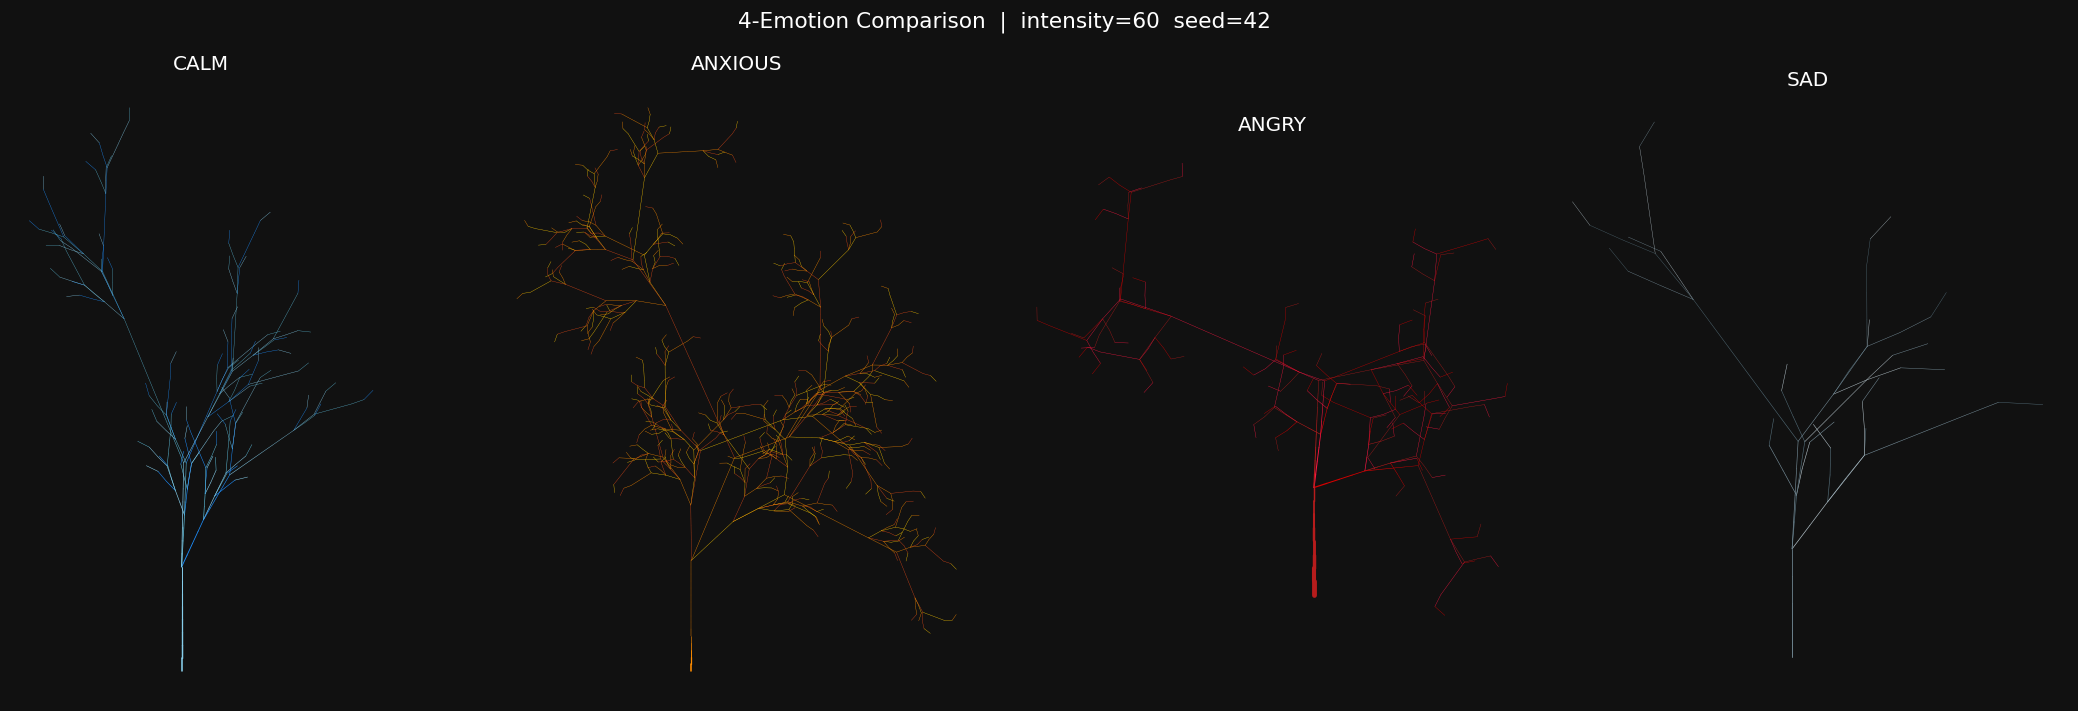

Saved → emotion_grid.png


In [8]:
COMPARE_INTENSITY = 60   # ← change it to 0 / 50 / 100 later
COMPARE_SEED      = 42

fig2, axes = plt.subplots(1, 4, figsize=(18, 6))
fig2.patch.set_facecolor('#111111')

for ax2, em in zip(axes, ['calm', 'anxious', 'angry', 'sad']):
    params = get_params(em, COMPARE_INTENSITY, COMPARE_SEED)
    random.seed(params['seed'])
    sentence = expand(AXIOM, RULES, params['depth'])
    segs = interpret(sentence,
                     step_len=params['step_len'],
                     base_angle=params['base_angle'],
                     angle_jitter=params['angle_jitter'],
                     downward_bias=params['downward_bias'],
                     line_weight=params['line_weight'],
                     weight_taper=params['weight_taper'],
                     colors=params['colors'],
                     seed=params['seed'])
    ax2.set_facecolor(BG_COLORS[em])
    for (x0,y0,x1,y1,col,lw) in segs:
        ax2.plot([x0,x1],[y0,y1],color=col,linewidth=lw,
                 solid_capstyle='round',solid_joinstyle='round')
    ax2.set_aspect('equal')
    ax2.axis('off')
    ax2.set_title(em.upper(), color='white', fontsize=12)

plt.suptitle(f'4-Emotion Comparison  |  intensity={COMPARE_INTENSITY}  seed={COMPARE_SEED}',
             color='white', fontsize=13)
plt.tight_layout()
plt.savefig('emotion_grid.png', dpi=150, bbox_inches='tight',
            facecolor=fig2.get_facecolor())
plt.show()
print('Saved → emotion_grid.png')